# Clase 7 — Detección de objetos con YOLO y Faster R-CNN

## Pregunta central

> ¿Cómo puede una empresa identificar qué objetos aparecen en una imagen y dónde están?

En esta clase usaremos dos detectores modernos ya entrenados. No vamos a entrenar redes ni estudiar su matemática interna. El objetivo es observar el flujo completo de inferencia, interpretar cajas y scores, y comparar dos maneras diferentes de resolver la misma tarea.

Trabajaremos con una escena urbana que podría pertenecer a una empresa de transporte. Intentaremos detectar un colectivo y peatones con:

- YOLO, una familia pensada para detectar de manera rápida;
- Faster R-CNN, una familia que primero propone regiones y luego las analiza.

La pregunta que acompañará todos los experimentos es:

imagen → modelo → cajas, clases y scores → decisión de negocio


## Objetivos

Al finalizar deberías poder:

- explicar qué devuelve un detector de objetos;
- reconocer la diferencia conceptual entre YOLO y Faster R-CNN;
- ejecutar ambos modelos sobre una misma imagen;
- interpretar clase, caja, score y umbral;
- medir una latencia aproximada sin confundirla con una garantía de tiempo real;
- conectar una detección con necesidades concretas de una empresa.

## Cómo trabajar

1. Ejecutá las celdas en orden.
2. Mirá primero la imagen y después la tabla.
3. No hace falta comprender cada línea de PyTorch o Ultralytics.
4. En la actividad final cambiá solamente las dos variables señaladas.


---
## 1. Repaso: clasificación no es detección

Un clasificador responde qué representa principalmente una imagen. Un detector puede devolver varios objetos y ubicarlos.

| Tarea | Entrada | Salida |
|---|---|---|
| Clasificación | una imagen | una categoría principal |
| Detección | una imagen | cero o más categorías, cajas y scores |

Cada detección contiene:

- clase: qué objeto propone el modelo;
- caja: dónde aparece, mediante cuatro coordenadas;
- score: qué tan fuerte fue la respuesta del modelo;
- umbral: el mínimo que nosotros exigimos para mostrarla.

Un score alto no prueba que el modelo tenga razón. Es necesario evaluar muchas imágenes representativas del problema real.


## Aplicaciones empresariales

| Sector | Objetos posibles | Decisión que podría apoyar |
|---|---|---|
| Transporte | vehículos, personas | ocupación de una zona o circulación |
| Logística | camiones, paquetes, pallets | seguimiento de flujo y detección de demoras |
| Industria | piezas, herramientas, elementos de seguridad | control visual y alertas para revisión |
| Retail | productos, carros, personas | reposición, disponibilidad y análisis operativo |
| Agricultura | maquinaria, animales, frutos | monitoreo de tareas y conteos aproximados |

Detectar no equivale a decidir. Una empresa todavía debe definir costos de error, privacidad, supervisión humana y condiciones de uso.


In [11]:
# PREPARACIÓN DEL NOTEBOOK
# No hace falta memorizar estas importaciones.

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from matplotlib.patches import Rectangle
from PIL import Image
from warnings import filterwarnings
filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))

In [12]:

%pip install certifi

import ssl
import urllib.request
import certifi

# Rutas directas relativas a la carpeta desde la que se ejecuta el notebook.
# Se evita buscar en carpetas padre o depender del nombre del proyecto.

ruta_imagen = Path.cwd() / "imagenes" / "escena_bus_peatones.jpg"
ruta_yolo_candidata = Path.cwd() / "modelos_cache" / "yolo11n.pt"

if not ruta_yolo_candidata.exists():
    ruta_yolo_candidata.parent.mkdir(parents=True, exist_ok=True)
    url_modelo = (
        "https://github.com/ultralytics/assets/releases/download/"
        "v8.3.0/yolo11n.pt"
    )
    contexto_ssl = ssl.create_default_context(cafile=certifi.where())

    print("Descargando modelo YOLO...")
    with urllib.request.urlopen(url_modelo, context=contexto_ssl) as respuesta:
        ruta_yolo_candidata.write_bytes(respuesta.read())
    print("Modelo descargado:", ruta_yolo_candidata)

if not ruta_imagen.exists():
    raise FileNotFoundError(f"No se encontró la imagen: {ruta_imagen}")

ruta_yolo = ruta_yolo_candidata if ruta_yolo_candidata.exists() else None

imagen = Image.open(ruta_imagen).convert("RGB")
print("Imagen:", ruta_imagen.name)
print("Tamaño:", imagen.size)
print("Modelo YOLO local disponible:", ruta_yolo is not None)
print("Dispositivo usado:", "CPU")

Note: you may need to restart the kernel to use updated packages.
Imagen: escena_bus_peatones.jpg
Tamaño: (1536, 1024)
Modelo YOLO local disponible: True
Dispositivo usado: CPU


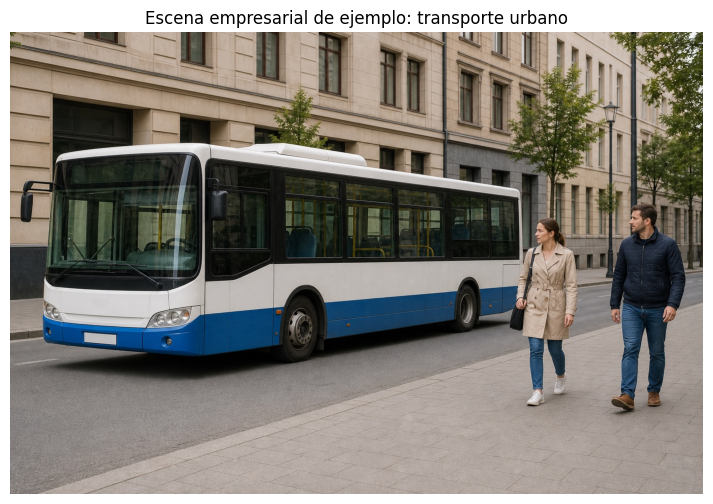

In [13]:
plt.figure(figsize=(12, 6))
plt.imshow(imagen)
plt.title("Escena empresarial de ejemplo: transporte urbano")
plt.axis("off")
plt.show()


### Antes de ejecutar los modelos

Observá la escena y escribí una predicción:

1. ¿Qué objetos esperás que ambos modelos encuentren?
2. ¿Qué objetos podrían confundir?
3. ¿Qué sería más costoso para una empresa de transporte: omitir una persona o mostrar una falsa alarma?

Estas preguntas definen cómo deberíamos interpretar los resultados y elegir un umbral.


---
## 2. YOLO: detectar en una sola pasada

YOLO significa You Only Look Once. La intuición es que el modelo procesa la imagen y produce directamente candidatos de cajas, clases y scores.

imagen → YOLO → cajas + clases + scores

Esta familia suele elegirse cuando la velocidad es importante, por ejemplo para analizar video. Sin embargo, el nombre tiempo real no es una garantía: depende del modelo, hardware, resolución, cantidad de cámaras y latencia máxima aceptable.


In [14]:
columnas_deteccion = ["clase", "score", "x1", "y1", "x2", "y2"]


def dibujar_detecciones(imagen, detecciones, umbral, titulo):
    """Dibuja las detecciones que superan el umbral elegido."""
    visibles = detecciones[detecciones["score"] >= umbral].copy()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(imagen)

    for _, fila in visibles.iterrows():
        ancho = fila["x2"] - fila["x1"]
        alto = fila["y2"] - fila["y1"]
        ax.add_patch(Rectangle(
            (fila["x1"], fila["y1"]),
            ancho,
            alto,
            fill=False,
            linewidth=2.5,
        ))
        ax.text(
            fila["x1"],
            max(0, fila["y1"] - 5),
            f"{fila['clase']}: {fila['score']:.2f}",
            backgroundcolor="white",
            fontsize=9,
        )

    ax.set_title(f"{titulo} — {len(visibles)} detección(es), umbral {umbral:.2f}")
    ax.axis("off")
    plt.show()
    return visibles


In [15]:
# EXPERIMENTO A: YOLO
UMBRAL_YOLO = 0.25
resultados_yolo = pd.DataFrame(columns=columnas_deteccion)
yolo_disponible = False
latencia_yolo = np.nan
error_yolo = None

try:
    if ruta_yolo is None:
        raise FileNotFoundError("No se encontró el modelo yolo11n.pt")

    from ultralytics import YOLO

    detector_yolo = YOLO(str(ruta_yolo))
    parametros_yolo = {
        "source": imagen,
        "imgsz": 640,
        "conf": 0.05,
        "device": "cpu",
        "verbose": False,
    }
    # Una primera pasada prepara operaciones internas; no la contamos.
    detector_yolo.predict(**parametros_yolo)
    inicio = perf_counter()
    salida_yolo = detector_yolo.predict(**parametros_yolo)[0]
    latencia_yolo = perf_counter() - inicio

    cajas = salida_yolo.boxes.xyxy.cpu().numpy()
    scores = salida_yolo.boxes.conf.cpu().numpy()
    clases = salida_yolo.boxes.cls.cpu().numpy().astype(int)

    resultados_yolo = pd.DataFrame({
        "clase": [salida_yolo.names[int(c)] for c in clases],
        "score": scores,
        "x1": cajas[:, 0],
        "y1": cajas[:, 1],
        "x2": cajas[:, 2],
        "y2": cajas[:, 3],
    })
    yolo_disponible = True

except Exception as error:
    error_yolo = f"{type(error).__name__}: {error}"

print("YOLO disponible:", yolo_disponible)
print(f"Latencia aproximada: {latencia_yolo:.3f} s" if yolo_disponible else error_yolo)
display(resultados_yolo.round(2))


YOLO disponible: True
Latencia aproximada: 0.055 s


,clase,score,x1,y1,x2,y2
0,bus,0.94,35.340000,243.990005,1136.079956,735.099976
1,person,0.92,1327.619995,373.630005,1498.750000,842.599976
2,person,0.86,1114.040039,411.209991,1260.790039,834.690002
3,handbag,0.21,1120.510010,476.059998,1173.989990,635.809998
4,handbag,0.20,1130.609985,474.190002,1175.900024,604.859985
5,handbag,0.17,1106.420044,598.599976,1144.209961,663.940002
6,handbag,0.08,1105.949951,530.150024,1148.199951,664.539978
7,handbag,0.07,1106.589966,474.989990,1168.280029,668.150024


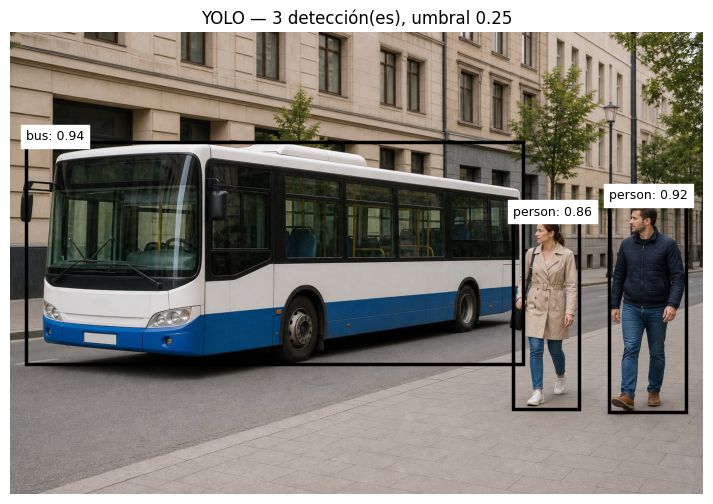

In [16]:
visibles_yolo = dibujar_detecciones(
    imagen,
    resultados_yolo,
    UMBRAL_YOLO,
    "YOLO",
)


### Interpretación empresarial

En esta escena, una empresa podría contar vehículos y personas visibles. Pero esta única imagen no permite saber:

- si una persona subió al colectivo;
- si es la misma persona que apareció antes;
- si existe peligro o una infracción;
- cuántas personas están dentro del vehículo.

Para responder esas preguntas harían falta otras señales, seguimiento entre cuadros, reglas de negocio y evaluación específica. El detector solo aporta observaciones candidatas.


---
## 3. Faster R-CNN: proponer regiones y analizarlas

Faster R-CNN trabaja conceptualmente en dos etapas:

imagen → propuestas de regiones → clasificación y ajuste de cajas

La primera parte busca zonas que podrían contener objetos. La segunda analiza esas zonas y refina la respuesta.

Esta familia suele priorizar una detección detallada, aunque normalmente necesita más cómputo que una versión pequeña de YOLO. No existe un ganador universal: el resultado depende del dataset, el tamaño del modelo, el hardware y el objetivo empresarial.


In [17]:
# EXPERIMENTO B: FASTER R-CNN
# Usamos una variante con MobileNet y entrada reducida para una demostración razonable en CPU.
UMBRAL_FASTER = 0.25
resultados_faster = pd.DataFrame(columns=columnas_deteccion)
faster_disponible = False
latencia_faster = np.nan
error_faster = None

try:
    from torchvision.models.detection import (
        FasterRCNN_MobileNet_V3_Large_320_FPN_Weights,
        fasterrcnn_mobilenet_v3_large_320_fpn,
    )

    pesos_faster = FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT
    categorias_faster = pesos_faster.meta["categories"]
    transformar_faster = pesos_faster.transforms()

    detector_faster = fasterrcnn_mobilenet_v3_large_320_fpn(
        weights=pesos_faster
    ).eval()

    with torch.inference_mode():
        # Primera pasada de preparación, fuera de la medición.
        tensor_imagen = transformar_faster(imagen)
        detector_faster([tensor_imagen])
        inicio = perf_counter()
        tensor_imagen = transformar_faster(imagen)
        salida_faster = detector_faster([tensor_imagen])[0]
    latencia_faster = perf_counter() - inicio

    cajas = salida_faster["boxes"].cpu().numpy()
    scores = salida_faster["scores"].cpu().numpy()
    clases = salida_faster["labels"].cpu().numpy().astype(int)

    resultados_faster = pd.DataFrame({
        "clase": [categorias_faster[int(c)] for c in clases],
        "score": scores,
        "x1": cajas[:, 0],
        "y1": cajas[:, 1],
        "x2": cajas[:, 2],
        "y2": cajas[:, 3],
    })
    # Conservamos candidatos desde 0.05 para experimentar luego con el umbral.
    resultados_faster = resultados_faster[resultados_faster["score"] >= 0.05]
    faster_disponible = True

except Exception as error:
    error_faster = f"{type(error).__name__}: {error}"

print("Faster R-CNN disponible:", faster_disponible)
print(f"Latencia aproximada: {latencia_faster:.3f} s" if faster_disponible else error_faster)
display(resultados_faster.round(2))


Faster R-CNN disponible: True
Latencia aproximada: 0.232 s


,clase,score,x1,y1,x2,y2
0,bus,1.00,57.980000,248.889999,1153.390015,739.349976
1,person,1.00,1112.979980,416.690002,1255.489990,821.840027
2,person,1.00,1313.439941,384.010010,1485.819946,847.000000
3,person,0.23,943.190002,432.640015,980.109985,478.609985
4,handbag,0.16,1125.040039,545.489990,1178.209961,652.770020
5,handbag,0.09,1113.199951,514.770020,1163.979980,677.210022
6,handbag,0.07,1301.569946,472.570007,1374.780029,596.590027


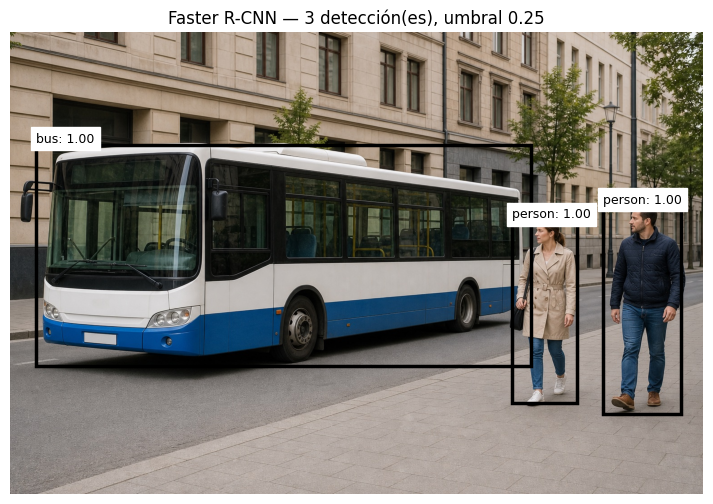

In [18]:
visibles_faster = dibujar_detecciones(
    imagen,
    resultados_faster,
    UMBRAL_FASTER,
    "Faster R-CNN",
)


---
## 4. Comparar sin declarar un ganador

Los dos modelos fueron entrenados previamente con categorías generales. Compararemos la misma imagen y el mismo umbral, pero esto no constituye una evaluación completa.

La latencia es una medición aproximada de una ejecución en esta computadora. La primera inferencia puede incluir trabajo de preparación y no representa necesariamente el rendimiento sostenido de un sistema con video.


In [19]:
UMBRAL_COMPARACION = 0.25


def resumen_modelo(nombre, detecciones, latencia, disponible):
    visibles = detecciones[detecciones["score"] >= UMBRAL_COMPARACION]
    return {
        "modelo": nombre,
        "disponible": disponible,
        "detecciones visibles": len(visibles),
        "personas": int((visibles["clase"] == "person").sum()),
        "colectivos": int((visibles["clase"] == "bus").sum()),
        "latencia aproximada (s)": latencia,
    }


comparacion = pd.DataFrame([
    resumen_modelo("YOLO", resultados_yolo, latencia_yolo, yolo_disponible),
    resumen_modelo(
        "Faster R-CNN",
        resultados_faster,
        latencia_faster,
        faster_disponible,
    ),
])

display(comparacion.style.format({"latencia aproximada (s)": "{:.3f}"}))


,modelo,disponible,detecciones visibles,personas,colectivos,latencia aproximada (s)
0,YOLO,True,3,2,1,0.055
1,Faster R-CNN,True,3,2,1,0.232


### Cómo elegir en una empresa

Una prueba útil no pregunta solamente cuál modelo es más rápido. Pregunta:

- ¿reconoce las categorías que necesita el negocio?
- ¿cuántos falsos positivos y falsos negativos produce?
- ¿funciona con cámaras, iluminación y ángulos reales?
- ¿cumple la latencia y el costo de infraestructura disponibles?
- ¿qué ocurre cuando no hay objetos o la imagen es mala?

Para una cámara en tiempo real podría importar mucho la velocidad. Para revisar fotografías al final del día quizá importe más reducir omisiones. La arquitectura es una parte de la decisión, no toda la solución.


---
## Desafío de programación — Calibrar un detector en condiciones difíciles

**Duración:** 35 a 45 minutos.

Las personas grandes y aisladas son un caso demasiado cómodo. Ahora vamos a probar los modelos con **oclusión**, **objetos pequeños**, **muchos objetos juntos**, **lluvia** y **poca luz**.

Cada escena tendrá su propia configuración. El trabajo consiste en observar una imagen, proponer valores, ejecutar un único intento, revisar las cajas y decidir qué modificar después. El notebook no probará todas las combinaciones ni elegirá automáticamente una ganadora. Vamos a modificar:

- el **modelo**: YOLO o Faster R-CNN;
- el **umbral de confianza**: cuánto debe confiar el modelo para aceptar una caja;
- el **tamaño de entrada de YOLO**: una imagen mayor puede revelar detalles, pero suele demorar más;
- el **IoU de NMS de YOLO**: controla cuándo dos cajas muy superpuestas se consideran la misma detección.


In [ ]:
# CARGA DE LAS TRES ESCENAS
archivos_prueba = {
    "Andén concurrido": "anden_concurrido.jpg",
    "Cajas de supermercado": "cajas_supermercado.jpg",
    "Tránsito con lluvia": "transito_lluvia_claro.jpg",
}

rutas_prueba = {}
for escenario, archivo in archivos_prueba.items():
    rutas_prueba[escenario] = (
        Path.cwd() / "imagenes" / archivo
        if (Path.cwd() / "imagenes" / archivo).exists()
        else Path.cwd() / "modulo_4" / "imagenes" / archivo
    )

faltantes = [nombre for nombre, ruta in rutas_prueba.items() if ruta is None]
if faltantes:
    raise FileNotFoundError(f"Faltan imágenes para: {faltantes}")

imagenes_prueba = {
    nombre: Image.open(ruta).convert("RGB")
    for nombre, ruta in rutas_prueba.items()
}

# Mostramos una escena por figura para poder inspeccionar objetos pequeños.
for nombre, imagen_prueba in imagenes_prueba.items():
    fig, eje = plt.subplots(figsize=(16, 10), dpi=120)
    eje.imshow(imagen_prueba)
    eje.set_title(nombre, fontsize=18)
    eje.axis("off")
    plt.tight_layout()
    plt.show()


NameError: name 'encontrar_recurso' is not defined

### Qué vamos a medir

Para comparar configuraciones usamos anotaciones manuales provistas para el ejercicio. En los grupos contamos cualquier clase equivalente: `car`, `bus`, `truck` y `motorcycle` cuentan como **vehículos**.

| Escena | Referencia | Dificultad principal |
|---|---|---|
| Andén concurrido | 35 personas | oclusiones, escala y poca luz |
| Cajas de supermercado | 9 personas | cuerpos parciales y fondo cargado |
| Tránsito con lluvia | 58 vehículos | objetos pequeños, reflejos y categorías parecidas |

Una **omisión** será más costosa que una falsa alarma. La comparación sigue siendo simplificada: evaluamos cantidades por grupo, no la posición exacta de cada caja.

> Importante: un conteo correcto puede esconder cajas mal ubicadas o duplicadas. Por eso el costo orienta la comparación, pero la inspección visual decide si la configuración es aceptable.


In [ ]:
# ANOTACIONES MANUALES Y GRUPOS DE CLASES
referencias = {
    "Andén concurrido": {"personas": 35},
    "Cajas de supermercado": {"personas": 9},
    "Tránsito con lluvia": {"vehículos": 58},
}

grupos_clases = {
    "personas": ["person"],
    "vehículos": ["car", "bus", "truck", "motorcycle"],
}


def detectar_yolo_ejercicio(imagen_prueba, tamano, iou_nms):
    inicio = perf_counter()
    salida = detector_yolo.predict(
        source=imagen_prueba, imgsz=tamano, conf=0.03,
        iou=iou_nms, max_det=300, device="cpu", verbose=False,
    )[0]
    latencia_ms = (perf_counter() - inicio) * 1000
    cajas = salida.boxes.xyxy.cpu().numpy()
    scores = salida.boxes.conf.cpu().numpy()
    clases = salida.boxes.cls.cpu().numpy().astype(int)

    detecciones = pd.DataFrame({
        "clase": [salida.names[int(c)] for c in clases],
        "score": scores,
        "x1": cajas[:, 0], "y1": cajas[:, 1],
        "x2": cajas[:, 2], "y2": cajas[:, 3],
    })
    return detecciones, latencia_ms


def detectar_faster_ejercicio(imagen_prueba):
    inicio = perf_counter()
    with torch.inference_mode():
        salida = detector_faster([transformar_faster(imagen_prueba)])[0]
    latencia_ms = (perf_counter() - inicio) * 1000

    cajas = salida["boxes"].cpu().numpy()
    scores = salida["scores"].cpu().numpy()
    clases = salida["labels"].cpu().numpy().astype(int)
    detecciones = pd.DataFrame({
        "clase": [categorias_faster[int(c)] for c in clases],
        "score": scores,
        "x1": cajas[:, 0], "y1": cajas[:, 1],
        "x2": cajas[:, 2], "y2": cajas[:, 3],
    })
    return detecciones[detecciones["score"] >= 0.03], latencia_ms


def calcular_errores(detecciones, referencia, umbral):
    visibles = detecciones[detecciones["score"] >= umbral]
    omisiones = 0
    falsas_alarmas = 0

    for grupo, cantidad_real in referencia.items():
        clases_validas = grupos_clases[grupo]
        cantidad_detectada = int(
            visibles["clase"].isin(clases_validas).sum()
        )
        omisiones += max(cantidad_real - cantidad_detectada, 0)
        falsas_alarmas += max(cantidad_detectada - cantidad_real, 0)

    return omisiones, falsas_alarmas


### Antes de empezar: qué significa cada parámetro

En cada imagen encontrarán nuevamente los mismos seis valores. Modifiquen **una variable por vez**, ejecuten esa imagen y comparen el resultado con el intento anterior.

#### `MODELO`

Puede ser `"YOLO"` o `"Faster R-CNN"`. Si eligen Faster R-CNN, el tamaño y el IoU NMS quedan bajo la configuración interna del modelo; el umbral y los costos siguen aplicándose.

#### `TAMANO_YOLO` — resolución de trabajo del modelo

YOLO no procesa necesariamente la fotografía con sus dimensiones originales. La redimensiona internamente a un tamaño de trabajo aproximado, expresado en píxeles.

- `320`: menos detalle, menor consumo y normalmente mayor velocidad;
- `640`: punto intermedio habitual;
- `960`: conserva mejor los objetos pequeños, pero requiere más tiempo y memoria.

Este valor **no cambia el tamaño con el que vemos la figura en el notebook**. Solo cambia la imagen que recibe el modelo. En estas escenas esperamos que una resolución mayor ayude con personas y vehículos lejanos.

#### `UMBRAL` — confianza mínima aceptada

Cada caja recibe un `score` entre 0 y 1. Con un umbral de `0.10` aceptamos cajas con al menos 10 % de confianza; con `0.50`, exigimos 50 %.

- umbral bajo → aparecen más objetos, pero también más falsas alarmas;
- umbral alto → quedan cajas más seguras, pero podemos omitir objetos reales.

El `conf=0.03` dentro de la función es solamente un piso técnico para conservar candidatos. Para el ejercicio modifiquen `UMBRAL`, no ese valor.

#### `IOU_NMS_YOLO` — eliminación de cajas repetidas

**IoU** mide cuánto se superponen dos cajas: `0` significa que no se tocan y `1` que son prácticamente iguales. **NMS** conserva la caja con mejor score y elimina otras que parecen representar el mismo objeto.

- IoU NMS `0.40` → eliminación agresiva: descarta cajas con una superposición moderada; puede borrar personas distintas que están muy juntas;
- IoU NMS `0.70` → eliminación permisiva: conserva más cajas cercanas; puede mantener detecciones duplicadas.

No buscamos el número más alto o más bajo: buscamos el que se comporte mejor en nuestras imágenes. En Faster R-CNN este parámetro queda con la configuración interna del modelo.

#### `COSTO_OMISION` y `COSTO_FALSA_ALARMA`

Transforman los errores en una prioridad de negocio. Con costo de omisión `2` y costo de falsa alarma `1`, dejar afuera un objeto real perjudica el doble que agregar uno inexistente.

### Método de trabajo

1. Ejecuten el punto de partida de una imagen.
2. Miren las cajas antes de mirar el costo: identifiquen omisiones, duplicados y etiquetas incorrectas.
3. Elijan **un solo parámetro** para el siguiente intento y anticipen qué debería cambiar.
4. Modifiquen la celda de esa imagen y ejecútenla nuevamente. Cada ejecución queda registrada en el historial.
5. Realicen al menos cuatro intentos por imagen y conserven la configuración que consideren más razonable.

El costo ayuda a comparar, pero no decide por ustedes: dos configuraciones con el mismo conteo pueden tener cajas visualmente muy diferentes.


In [ ]:
if not yolo_disponible or not faster_disponible:
    raise RuntimeError("Los dos modelos deben estar disponibles para el ejercicio.")

historial_intentos = []
colores_clase = {
    "person": "deepskyblue",
    "car": "lime",
    "bus": "orange",
    "truck": "magenta",
    "motorcycle": "yellow",
}


def ejecutar_intento(
    escenario, modelo, tamano_yolo, umbral, iou_nms_yolo,
    costo_omision, costo_falsa_alarma,
):
    """Ejecuta una sola configuración, la registra y dibuja sus cajas."""
    if modelo not in ["YOLO", "Faster R-CNN"]:
        raise ValueError("MODELO debe ser 'YOLO' o 'Faster R-CNN'.")
    if not 0.03 <= umbral <= 1:
        raise ValueError("UMBRAL debe estar entre 0.03 y 1.")
    if modelo == "YOLO" and not 0 < iou_nms_yolo <= 1:
        raise ValueError("IOU_NMS_YOLO debe estar entre 0 y 1.")

    imagen_prueba = imagenes_prueba[escenario]
    if modelo == "YOLO":
        detecciones, latencia_ms = detectar_yolo_ejercicio(
            imagen_prueba, tamano_yolo, iou_nms_yolo
        )
        tamano_usado = tamano_yolo
        iou_usado = f"{iou_nms_yolo:.2f}"
    else:
        detecciones, latencia_ms = detectar_faster_ejercicio(
            imagen_prueba
        )
        tamano_usado = "interno"
        iou_usado = "interno"

    omisiones, falsas = calcular_errores(
        detecciones, referencias[escenario], umbral
    )
    costo = omisiones * costo_omision + falsas * costo_falsa_alarma
    numero_intento = 1 + sum(
        fila["escenario"] == escenario for fila in historial_intentos
    )
    resultado = {
        "escenario": escenario,
        "intento": numero_intento,
        "modelo": modelo,
        "tamaño": tamano_usado,
        "umbral": umbral,
        "iou NMS": iou_usado,
        "omisiones": omisiones,
        "falsas alarmas": falsas,
        "costo": costo,
        "latencia (ms)": latencia_ms,
    }
    historial_intentos.append(resultado)
    display(pd.DataFrame([resultado]).style.format({
        "umbral": "{:.2f}", "latencia (ms)": "{:.1f}"
    }))

    visibles = detecciones[detecciones["score"] >= umbral].copy()
    clases_evaluadas = [
        clase
        for grupo in referencias[escenario]
        for clase in grupos_clases[grupo]
    ]
    visibles = visibles[visibles["clase"].isin(clases_evaluadas)]

    fig, eje = plt.subplots(figsize=(16, 10), dpi=120)
    eje.imshow(imagen_prueba)
    for _, fila in visibles.iterrows():
        color = colores_clase.get(fila["clase"], "lime")
        eje.add_patch(Rectangle(
            (fila["x1"], fila["y1"]),
            fila["x2"] - fila["x1"],
            fila["y2"] - fila["y1"],
            fill=False, linewidth=3, edgecolor=color,
        ))
        eje.text(
            fila["x1"], max(0, fila["y1"] - 5),
            f"{fila['clase']}: {fila['score']:.2f}",
            backgroundcolor="white", color="black", fontsize=10,
        )
    eje.set_title(
        f"{escenario} — intento {numero_intento}: "
        f"{len(visibles)} cajas evaluadas",
        fontsize=18,
    )
    eje.axis("off")
    plt.tight_layout()
    plt.show()
    return resultado


print("Preparación lista. No vuelvan a ejecutar esta celda o se borrará el historial.")


### Imagen 1 — Andén concurrido

Hay 35 personas anotadas. Empiecen con la configuración propuesta y realicen al menos cuatro intentos. En cada repetición cambien una sola variable.

Orden sugerido: primero tamaño, después umbral y finalmente IoU NMS. Observen si un NMS agresivo elimina personas diferentes que están muy juntas.


In [ ]:
# CONFIGURACIÓN DEL ANDÉN — modifiquen y vuelvan a ejecutar esta celda
MODELO_ANDEN = "YOLO"
TAMANO_YOLO_ANDEN = 320
UMBRAL_ANDEN = 0.25
IOU_NMS_YOLO_ANDEN = 0.70
COSTO_OMISION_ANDEN = 3
COSTO_FALSA_ALARMA_ANDEN = 1

resultado_anden = ejecutar_intento(
    escenario="Andén concurrido",
    modelo=MODELO_ANDEN,
    tamano_yolo=TAMANO_YOLO_ANDEN,
    umbral=UMBRAL_ANDEN,
    iou_nms_yolo=IOU_NMS_YOLO_ANDEN,
    costo_omision=COSTO_OMISION_ANDEN,
    costo_falsa_alarma=COSTO_FALSA_ALARMA_ANDEN,
)


### Imagen 2 — Cajas de supermercado

Hay 9 personas anotadas, varias pequeñas o parcialmente ocultas. Realicen al menos cuatro intentos. No copien automáticamente la configuración del andén: el fondo, la escala y la cantidad de personas son diferentes.

Presten atención a una trampa: bajar el umbral puede acercar el conteo a 9 gracias a cajas incorrectas. Revisen a qué persona corresponde cada caja.


In [ ]:
# CONFIGURACIÓN DEL SUPERMERCADO — modifiquen y vuelvan a ejecutar esta celda
MODELO_SUPERMERCADO = "YOLO"
TAMANO_YOLO_SUPERMERCADO = 640
UMBRAL_SUPERMERCADO = 0.25
IOU_NMS_YOLO_SUPERMERCADO = 0.70
COSTO_OMISION_SUPERMERCADO = 2
COSTO_FALSA_ALARMA_SUPERMERCADO = 1

resultado_supermercado = ejecutar_intento(
    escenario="Cajas de supermercado",
    modelo=MODELO_SUPERMERCADO,
    tamano_yolo=TAMANO_YOLO_SUPERMERCADO,
    umbral=UMBRAL_SUPERMERCADO,
    iou_nms_yolo=IOU_NMS_YOLO_SUPERMERCADO,
    costo_omision=COSTO_OMISION_SUPERMERCADO,
    costo_falsa_alarma=COSTO_FALSA_ALARMA_SUPERMERCADO,
)


### Imagen 3 — Tránsito con lluvia

Hay 58 vehículos anotados. Para el conteo, `car`, `bus`, `truck` y `motorcycle` pertenecen al mismo grupo. Realicen al menos cuatro intentos.

En esta imagen el tamaño de entrada debería tener un efecto fuerte porque muchos vehículos ocupan pocos píxeles. Revisen también si una misma unidad aparece con dos etiquetas diferentes.


In [ ]:
# CONFIGURACIÓN DEL TRÁNSITO — modifiquen y vuelvan a ejecutar esta celda
MODELO_TRANSITO = "YOLO"
TAMANO_YOLO_TRANSITO = 640
UMBRAL_TRANSITO = 0.25
IOU_NMS_YOLO_TRANSITO = 0.70
COSTO_OMISION_TRANSITO = 2
COSTO_FALSA_ALARMA_TRANSITO = 1

resultado_transito = ejecutar_intento(
    escenario="Tránsito con lluvia",
    modelo=MODELO_TRANSITO,
    tamano_yolo=TAMANO_YOLO_TRANSITO,
    umbral=UMBRAL_TRANSITO,
    iou_nms_yolo=IOU_NMS_YOLO_TRANSITO,
    costo_omision=COSTO_OMISION_TRANSITO,
    costo_falsa_alarma=COSTO_FALSA_ALARMA_TRANSITO,
)


### Historial de intentos

La tabla siguiente muestra exactamente lo que probaron; no crea combinaciones ni ordena automáticamente por ganador. Si desean conservar el historial, vuelvan a ejecutar solamente las tres celdas de configuración, no la celda que define `historial_intentos`.


In [ ]:
historial_df = pd.DataFrame(historial_intentos)
display(historial_df.style.format({
    "umbral": "{:.2f}", "latencia (ms)": "{:.1f}"
}))
print(f"Intentos registrados: {len(historial_df)}")


### Selección manual y entrega

Después de realizar al menos cuatro intentos por imagen, completen los números de intento elegidos en la próxima celda. No elijan solamente por costo: vuelvan a mirar las cajas de esos tres intentos.


In [ ]:
# Reemplacen None por el número de intento elegido para cada imagen
INTENTO_ELEGIDO_ANDEN = 2
INTENTO_ELEGIDO_SUPERMERCADO = 1
INTENTO_ELEGIDO_TRANSITO = 1

elecciones = {
    "Andén concurrido": INTENTO_ELEGIDO_ANDEN,
    "Cajas de supermercado": INTENTO_ELEGIDO_SUPERMERCADO,
    "Tránsito con lluvia": INTENTO_ELEGIDO_TRANSITO,
}

if any(numero is None for numero in elecciones.values()):
    print("Completen los tres números después de terminar los intentos.")
else:
    seleccion_final = historial_df[
        historial_df.apply(
            lambda fila: elecciones[fila["escenario"]] == fila["intento"],
            axis=1,
        )
    ]
    display(seleccion_final)


Agreguen una celda Markdown con respuestas breves:

1. ¿Qué configuración eligieron para cada imagen y por qué son diferentes?
2. ¿Qué parámetro tuvo mayor efecto en el andén, en el supermercado y en el tránsito?
3. Muestren un intento que mejoró el conteo pero empeoró visualmente las cajas.
4. ¿En cuál imagen fue más útil aumentar el tamaño?
5. ¿En cuál imagen el IoU NMS eliminó objetos reales o conservó duplicados?
6. ¿Qué configuración usarían si debieran procesar las tres cámaras con un solo servidor?

### Fuentes de las imágenes

- Andén: Pithecanthropus4152, CC BY-SA 3.0, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Crowded_platform_II.jpg).
- Supermercado: Michael W. Pendergrass / U.S. Navy, dominio público, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:US_Navy_020813-N-3235P-532_A_Navy_family_unloads_their_shopping_cart_while_purchasing_groceries_at_the_Navy_Commissary_located_just_outside_Naval_Air_Station_Oceana.jpg).
- Tránsito: epSos.de, CC BY 2.0, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Driving_Cars_in_a_Traffic_Jam.jpg).


---
## Límites y uso responsable

- Los modelos preentrenados solo conocen las categorías de su entrenamiento.
- Una caja no identifica a una persona ni explica qué está haciendo.
- Cámaras reales cambian por iluminación, clima, movimiento y ángulo.
- Umbrales bajos muestran más candidatos y también más falsas alarmas.
- Medir apenas tres imágenes no demuestra funcionamiento en tiempo real.
- El uso sobre personas requiere revisar privacidad, permisos y consecuencias.
- Una alerta importante debería permitir revisión humana y registro del contexto.

## Síntesis

- La detección devuelve clases, cajas y scores.
- YOLO produce detecciones en una sola pasada conceptual y suele favorecer velocidad.
- Faster R-CNN propone regiones y luego las analiza.
- El umbral es una decisión del sistema, no una verdad del modelo.
- Tiempo real depende del sistema completo, no solo del nombre de la arquitectura.
- Una empresa debe evaluar con sus propias imágenes y costos de error.

## Comprobación final

1. ¿Qué información agrega una caja frente a una clasificación?
2. ¿Cuál es la diferencia conceptual entre YOLO y Faster R-CNN?
3. ¿Por qué subir el umbral puede ocultar objetos reales?
4. ¿Qué habría que medir antes de implementar un detector en una empresa?
